<a href="https://colab.research.google.com/github/silvioguerreiro/Silvioguerreiro-1TIAOS_2026_FASE_5_Tratores-Digitais/blob/main/Silvio_Prestes_Guerreiro_Junior_RM567958_fase5_entrega_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto FIAP Fase 5 — Machine Learning e Computação em Nuvem

Este notebook foi elaborado para responder à atividade da **Fase 5** com base no dataset `crop_yield.csv` e nos conteúdos dos capítulos de **Machine Learning sem supervisão**, **regressão supervisionada**, **segurança**, **direito digital** e **cloud computing** da FIAP.

## Objetivos

1. Fazer a análise exploratória da base.
2. Identificar tendências de produtividade por **clusterização**.
3. Detectar **cenários discrepantes (outliers)**.
4. Construir e comparar **cinco modelos de regressão supervisionada**.


## Observação importante

A análise encontrou uma limitação estrutural relevante da base: existem **39 combinações climáticas únicas**, repetidas para as **4 culturas**. Isso significa que o modelo aprende fortemente o efeito da cultura e, em menor grau, as variações climáticas.

In [ ]:
import sys
import subprocess
import importlib.util

for pkg in ["xgboost", "threadpoolctl"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


In [ ]:
import warnings, os, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threadpoolctl import threadpool_limits

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def make_onehot_encoder(dense=False):
    params = {"handle_unknown": "ignore"}
    if dense:
        try:
            return OneHotEncoder(sparse_output=False, **params)
        except TypeError:
            return OneHotEncoder(sparse=False, **params)
    return OneHotEncoder(**params)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Leitura da base

In [ ]:
df = pd.read_csv("/content/sample_data/crop_yield.csv")
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [ ]:
df.shape

(156, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


## 2. Análise exploratória

In [ ]:
summary = pd.DataFrame({
    "coluna": df.columns,
    "tipo": [str(t) for t in df.dtypes],
    "nulos": df.isna().sum().values,
    "n_unicos": [df[c].nunique() for c in df.columns]
})
summary

,coluna,tipo,nulos,n_unicos
0,Crop,object,0,4
1,Precipitation (mm day-1),float64,0,39
2,Specific Humidity at 2 Meters (g/kg),float64,0,33
3,Relative Humidity at 2 Meters (%),float64,0,38
4,Temperature at 2 Meters (C),float64,0,29
5,Yield,int64,0,155


In [ ]:
print("Duplicatas completas:", df.duplicated().sum())
print("Culturas:", df["Crop"].unique().tolist())
print("Quantidade de culturas:", df["Crop"].nunique())

Duplicatas completas: 0
Culturas: ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']
Quantidade de culturas: 4


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,156,4,"Cocoa, beans",39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Precipitation (mm day-1),156.0,NaN,NaN,NaN,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Specific Humidity at 2 Meters (g/kg),156.0,NaN,NaN,NaN,18.203077,0.293923,17.54,18.03,18.27,18.4,18.7
Relative Humidity at 2 Meters (%),156.0,NaN,NaN,NaN,84.737692,0.996226,82.11,84.12,84.85,85.51,86.1
Temperature at 2 Meters (C),156.0,NaN,NaN,NaN,26.18359,0.26105,25.56,26.02,26.13,26.3,26.81
Yield,156.0,NaN,NaN,NaN,56153.096154,70421.958897,5249.0,8327.75,18871.0,67518.75,203399.0


In [ ]:
group_stats = (
    df.groupby("Crop")
      .agg(
          registros=("Crop", "count"),
          media_rendimento=("Yield", "mean"),
          mediana_rendimento=("Yield", "median"),
          desvio_rendimento=("Yield", "std"),
          minimo_rendimento=("Yield", "min"),
          maximo_rendimento=("Yield", "max")
      )
      .sort_values("media_rendimento", ascending=False)
)
group_stats

,registros,media_rendimento,mediana_rendimento,desvio_rendimento,minimo_rendimento,maximo_rendimento
Crop,,,,,,
Oil palm fruit,39,175804.692308,175629.0,14919.869752,142425,203399
"Rice, paddy",39,32099.666667,31101.0,4789.948436,24686,42550
"Cocoa, beans",39,8883.128205,8848.0,1745.030586,5765,13056
"Rubber, natural",39,7824.897436,7817.0,1600.255042,5249,10285


### 2.1. Verificação de limitação estrutural da base

Aqui verificamos quantas combinações climáticas realmente existem. Se houver poucas combinações únicas, repetidas entre culturas diferentes, isso limita a capacidade de generalização causal do modelo.

In [ ]:
weather_cols = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)"
]

unique_weather = df[weather_cols].drop_duplicates()
print("Linhas totais:", len(df))
print("Combinações climáticas únicas:", len(unique_weather))
print("Linhas repetidas apenas no bloco climático:", df[weather_cols].duplicated().sum())

unique_weather.head()

Linhas totais: 156
Combinações climáticas únicas: 39
Linhas repetidas apenas no bloco climático: 117


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
0,2248.92,17.72,83.40,26.01
1,1938.42,17.54,82.11,26.11
2,2301.54,17.81,82.79,26.24
3,2592.35,17.61,85.07,25.56
4,2344.72,17.61,84.12,25.76


### 2.2. Distribuição do rendimento por cultura

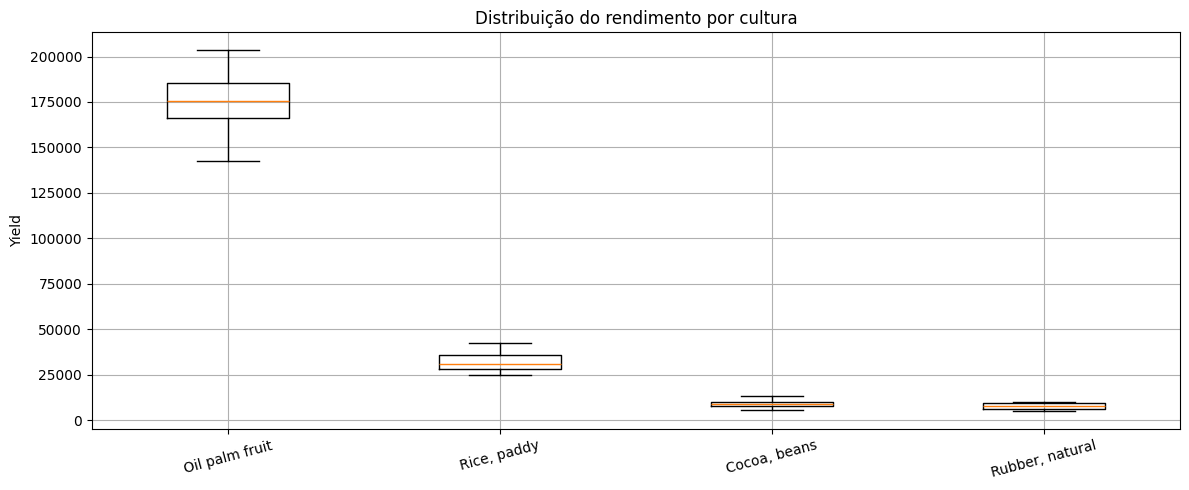

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ordered = group_stats.index.tolist()

data_to_plot = [df.loc[df["Crop"] == crop, "Yield"].values for crop in ordered]
ax.boxplot(data_to_plot, labels=ordered, vert=True)
ax.set_title("Distribuição do rendimento por cultura")
ax.set_ylabel("Yield")
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig("grafico_yield_por_cultura.png", dpi=200, bbox_inches="tight")
plt.show()

### 2.3. Correlação entre variáveis numéricas

In [ ]:
corr = df.drop(columns=["Crop"]).corr()
corr

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Precipitation (mm day-1),1.000000,0.488483,0.749464,-0.083927,0.018830
Specific Humidity at 2 Meters (g/kg),0.488483,1.000000,0.436687,0.699230,0.012651
Relative Humidity at 2 Meters (%),0.749464,0.436687,1.000000,-0.337313,0.000008
Temperature at 2 Meters (C),-0.083927,0.699230,-0.337313,1.000000,0.013007
Yield,0.018830,0.012651,0.000008,0.013007,1.000000


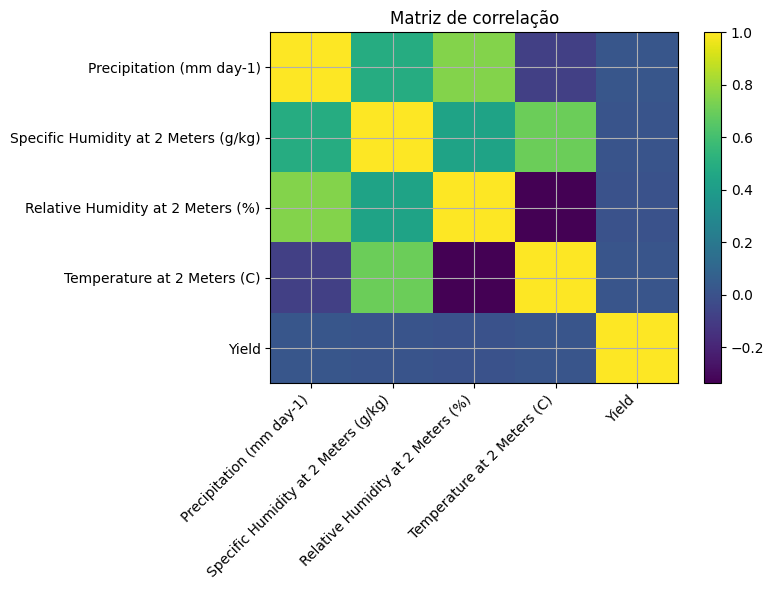

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Matriz de correlação")
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig("grafico_correlacao.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Clusterização para identificar tendências de produtividade

Conforme a proposta da disciplina, vamos usar técnicas não supervisionadas para encontrar padrões de produtividade.

### Estratégia adotada
- **K-Means** para descobrir grupos de comportamento.
- **DBSCAN** para detectar **outliers**.
- **PCA** para visualizar a distribuição em 2 dimensões.

Na clusterização principal, usamos:
- variáveis climáticas,
- rendimento,
- cultura (codificada via One-Hot Encoding).

In [ ]:
cat_cols = ["Crop"]
cluster_num_cols = weather_cols + ["Yield"]

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cluster_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder(dense=True))
        ]), cat_cols)
    ],
    sparse_threshold=0
)

X_cluster = cluster_preprocessor.fit_transform(df[cat_cols + cluster_num_cols])
X_cluster.shape

(156, 9)

### 3.1. Escolha do número de clusters (K-Means)

In [ ]:
k_results = []
with threadpool_limits(limits=1):
    for k in range(2, 9):
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_cluster)
        k_results.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_cluster, labels)
        })

k_results_df = pd.DataFrame(k_results)
k_results_df

,k,inertia,silhouette
0,2,652.974109,0.269436
1,3,500.130649,0.271373
2,4,394.494792,0.309074
3,5,342.870418,0.322042
4,6,306.498800,0.297754
5,7,273.152757,0.305146
6,8,244.823828,0.300730


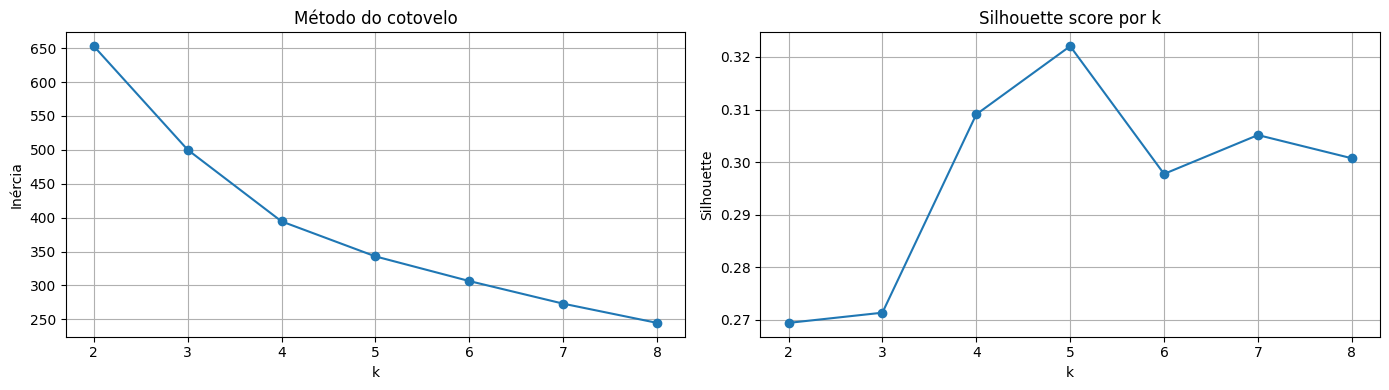

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_results_df["k"], k_results_df["inertia"], marker="o")
axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

axes[1].plot(k_results_df["k"], k_results_df["silhouette"], marker="o")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
fig.savefig("grafico_escolha_kmeans.png", dpi=200, bbox_inches="tight")
plt.show()

**Escolha adotada:** `k = 5`.

Justificativa:
- entre os valores testados, `k=5` apresentou o melhor silhouette score;
- a segmentação resultante ficou interpretável;
- os grupos separaram bem a cultura de maior produtividade (**Oil palm fruit**) e também subdividiram faixas climáticas/produtivas.

In [ ]:
with threadpool_limits(limits=1):
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
    df["cluster_kmeans"] = kmeans.fit_predict(X_cluster)

cluster_summary = (
    df.groupby("cluster_kmeans")
      .agg(
          registros=("Yield", "count"),
          media_yield=("Yield", "mean"),
          mediana_yield=("Yield", "median"),
          min_yield=("Yield", "min"),
          max_yield=("Yield", "max")
      )
      .round(2)
)

cluster_summary

,registros,media_yield,mediana_yield,min_yield,max_yield
cluster_kmeans,,,,,
0,36,29671.42,9353.5,5571,189896
1,51,16624.00,9880.0,5249,37972
2,15,174281.93,169783.0,150428,203399
3,21,177963.43,180323.0,160862,199074
4,33,14922.03,9718.0,5765,29918


In [ ]:
cluster_crop = pd.crosstab(df["cluster_kmeans"], df["Crop"])
cluster_crop

Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster_kmeans,,,,
0,11,3,11,11
1,17,0,17,17
2,0,15,0,0
3,0,21,0,0
4,11,0,11,11


### 3.2. Visualização com PCA

In [ ]:
with threadpool_limits(limits=1):
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_cluster)

df["pca1"] = pcs[:, 0]
df["pca2"] = pcs[:, 1]

print("Variância explicada pela PCA (2 componentes):", pca.explained_variance_ratio_.sum().round(4))
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

Variância explicada pela PCA (2 componentes): 0.6501
PC1: 0.3724
PC2: 0.2777


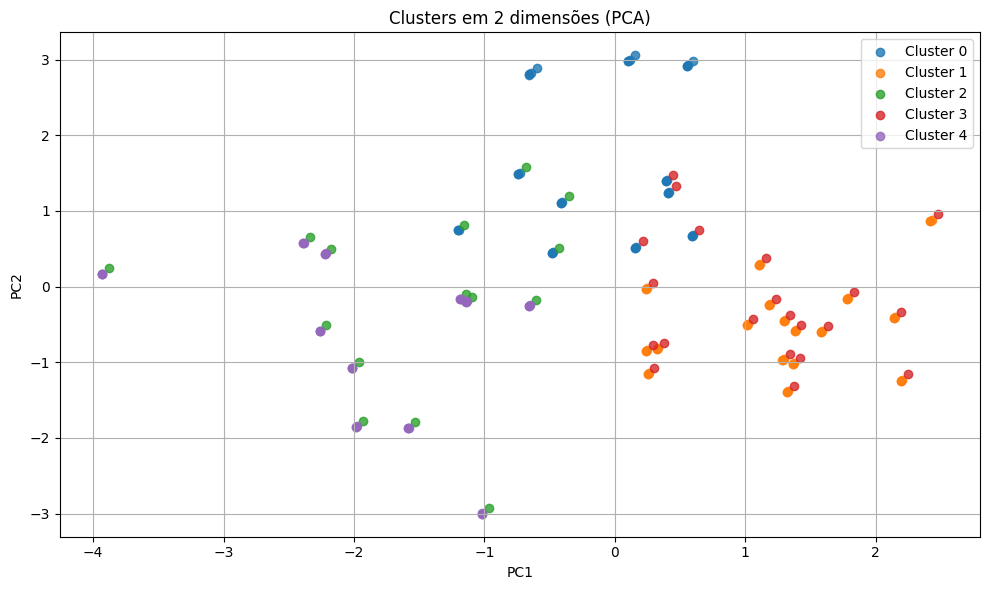

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for cluster_id in sorted(df["cluster_kmeans"].unique()):
    part = df[df["cluster_kmeans"] == cluster_id]
    ax.scatter(part["pca1"], part["pca2"], label=f"Cluster {cluster_id}", alpha=0.8)

ax.set_title("Clusters em 2 dimensões (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
fig.savefig("grafico_clusters_pca.png", dpi=200, bbox_inches="tight")
plt.show()

### 3.3. Interpretação dos clusters

Leitura dos grupos encontrados:

- **Clusters 2 e 3** concentram principalmente **Oil palm fruit**, a cultura com maior rendimento médio.
- **Clusters 1 e 4** agrupam cenários de menor rendimento médio, especialmente as culturas de menor escala produtiva.
- **Cluster 0** funciona como faixa intermediária, misturando culturas e regimes climáticos.

Em termos de negócio, isso sugere que:
1. a variável **Crop** explica grande parte da diferença de rendimento;
2. as condições climáticas ajudam a subdividir a produtividade dentro de grandes faixas;
3. o dataset parece representar mais uma combinação de **tipo de cultura + cenário climático** do que uma série totalmente independente por cultura.

## 4. Detecção de outliers com DBSCAN

Para detectar cenários climáticos discrepantes, foi usado o **DBSCAN** nas variáveis climáticas padronizadas.

Escolha técnica:
- usar somente o bloco climático evita que o rendimento da cultura dominante esconda anomalias meteorológicas;
- os outliers encontrados representam **perfis climáticos incomuns**, repetidos nas quatro culturas.

In [ ]:
X_weather = StandardScaler().fit_transform(df[weather_cols])

dbscan = DBSCAN(eps=1.2, min_samples=5)
df["cluster_dbscan_weather"] = dbscan.fit_predict(X_weather)

n_clusters = len(set(df["cluster_dbscan_weather"])) - (1 if -1 in df["cluster_dbscan_weather"].unique() else 0)
n_outliers = int((df["cluster_dbscan_weather"] == -1).sum())

print("Clusters DBSCAN (sem contar ruído):", n_clusters)
print("Quantidade de registros marcados como outlier:", n_outliers)

Clusters DBSCAN (sem contar ruído): 4
Quantidade de registros marcados como outlier: 16


In [ ]:
outlier_rows = df[df["cluster_dbscan_weather"] == -1].copy()
outlier_profiles = outlier_rows[weather_cols].drop_duplicates().sort_values(weather_cols)
outlier_profiles

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
9,1934.62,17.94,83.43,26.21
1,1938.42,17.54,82.11,26.11
3,2592.35,17.61,85.07,25.56
36,2967.41,18.67,85.48,26.46


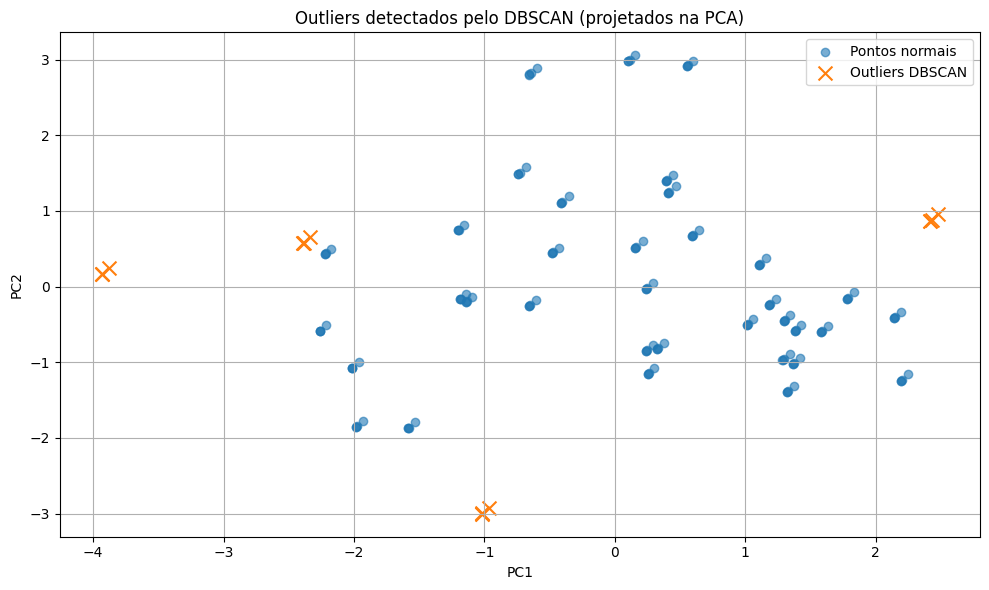

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
normal = df[df["cluster_dbscan_weather"] != -1]
outliers = df[df["cluster_dbscan_weather"] == -1]

ax.scatter(normal["pca1"], normal["pca2"], label="Pontos normais", alpha=0.6)
ax.scatter(outliers["pca1"], outliers["pca2"], label="Outliers DBSCAN", alpha=1.0, marker="x", s=100)

ax.set_title("Outliers detectados pelo DBSCAN (projetados na PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
fig.savefig("grafico_outliers_dbscan.png", dpi=200, bbox_inches="tight")
plt.show()

**Conclusão sobre os outliers:**

O DBSCAN marcou **16 registros** como outliers, que correspondem a **4 perfis climáticos únicos**, repetidos nas 4 culturas.

Esses pontos podem ser tratados como:
- cenários meteorológicos raros;
- candidatos a monitoramento especial;
- exemplos que merecem validação com especialistas do domínio antes de remoção definitiva.

## 5. Modelagem preditiva — regressão supervisionada

Seguindo as boas práticas vistas na disciplina:
- foi usado **hold-out** para separar treino e teste;
- dentro do conjunto de treino foi usada **validação cruzada 5-fold**;
- o pré-processamento foi feito por **pipeline**, evitando vazamento de dados;
- as métricas avaliadas foram:
  - **MAE**
  - **RMSE**
  - **R²**
  - **MAPE**

### Modelos comparados
1. Regressão Linear
2. KNN Regressor
3. Decision Tree Regressor
4. Random Forest Regressor
5. XGBoost Regressor

In [ ]:
X = df[cat_cols + weather_cols].copy()
y = df["Yield"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df["Crop"]   # garante equilíbrio das culturas em treino/teste
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), weather_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ]), cat_cols)
    ]
)

models = {
    "LinearRegression": LinearRegression(),
    "KNNRegressor": KNeighborsRegressor(n_neighbors=5, weights="distance"),
    "DecisionTree": DecisionTreeRegressor(max_depth=6, min_samples_leaf=2, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    )
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error"
}

results = []
fitted_models = {}

with threadpool_limits(limits=1):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        pipe = Pipeline([
            ("preprocessor", reg_preprocessor),
            ("model", model)
        ])

        cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        fitted_models[name] = pipe

        results.append({
            "modelo": name,
            "cv_mae": -cv_res["test_mae"].mean(),
            "cv_rmse": -cv_res["test_rmse"].mean(),
            "cv_r2": cv_res["test_r2"].mean(),
            "cv_mape": -cv_res["test_mape"].mean(),
            "test_mae": mean_absolute_error(y_test, preds),
            "test_rmse": root_mean_squared_error(y_test, preds),
            "test_r2": r2_score(y_test, preds),
            "test_mape": mean_absolute_percentage_error(y_test, preds)
        })

results_df = pd.DataFrame(results).sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
results_df.round(4)

,modelo,cv_mae,cv_rmse,cv_r2,cv_mape,test_mae,test_rmse,test_r2,test_mape
0,LinearRegression,5446.5273,8007.3329,0.9865,0.2212,4988.8920,8543.6294,0.9840,0.1632
1,XGBoost,5062.4151,7768.5801,0.9869,0.1607,4739.7178,9027.0020,0.9821,0.1562
2,RandomForest,4599.5044,7847.5224,0.9870,0.1273,4679.3994,9698.6442,0.9794,0.1104
3,DecisionTree,5393.5040,9829.1247,0.9793,0.1329,6179.0605,11536.7366,0.9708,0.1500
4,KNNRegressor,21796.7828,33811.6364,0.7384,1.1089,15387.5480,33569.8209,0.7528,0.5385


In [ ]:
best_model_name = results_df.loc[0, "modelo"]
best_model_name

'LinearRegression'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


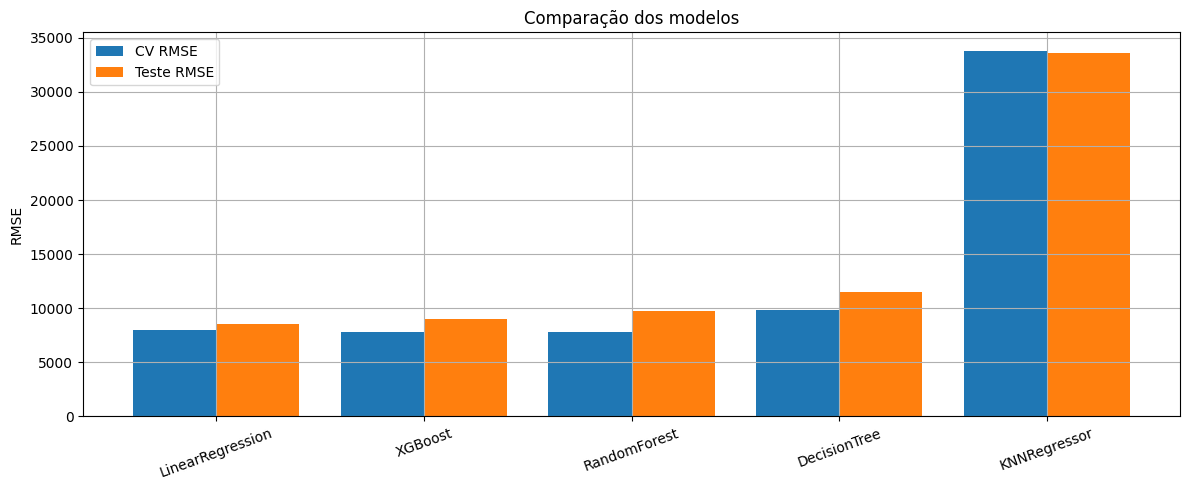

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results_df))
ax.bar(x - 0.2, results_df["cv_rmse"], width=0.4, label="CV RMSE")
ax.bar(x + 0.2, results_df["test_rmse"], width=0.4, label="Teste RMSE")

ax.set_xticks(x)
ax.set_xticklabels(results_df["modelo"], rotation=20)
ax.set_ylabel("RMSE")
ax.set_title("Comparação dos modelos")
ax.legend()
plt.tight_layout()
fig.savefig("grafico_comparacao_modelos.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.1. Resultado dos modelos

Com os parâmetros testados neste notebook, o melhor desempenho geral no conjunto de teste foi da **Regressão Linear**, seguida de **XGBoost** e **Random Forest**.

Isso faz sentido por causa da própria estrutura do dataset:
- a cultura explica grande parte do rendimento;
- as relações parecem relativamente estáveis dentro da base;
- o efeito linear com cultura codificada consegue capturar bem a variação principal.

Ao mesmo tempo, o **Random Forest** apresentou bom comportamento em erro percentual (MAPE), o que mostra que ele também é um candidato forte.

### 5.2. Modelo final selecionado

In [ ]:
best_model = fitted_models[best_model_name]
best_preds = best_model.predict(X_test)

pred_table = X_test.copy()
pred_table["y_real"] = y_test.values
pred_table["y_pred"] = best_preds
pred_table["erro_absoluto"] = (pred_table["y_real"] - pred_table["y_pred"]).abs()

pred_table.sort_values("erro_absoluto", ascending=False).head(10)

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),y_real,y_pred,erro_absoluto
56,Oil palm fruit,2362.80,18.70,84.03,26.79,142425,180648.500468,38223.500468
52,Oil palm fruit,2504.70,18.19,85.45,26.02,160862,175430.486972,14568.486972
47,Oil palm fruit,2061.61,17.80,84.36,25.88,183004,172608.000070,10395.999930
74,Oil palm fruit,2410.13,18.58,83.45,26.81,172601,181341.811274,8740.811274
45,Oil palm fruit,2326.09,18.09,84.63,26.11,166042,174575.026687,8533.026687
63,Oil palm fruit,2363.63,18.35,84.92,26.28,184629,176293.634858,8335.365142
85,"Rice, paddy",2718.08,18.30,85.43,26.12,25251,33423.505320,8172.505320
59,Oil palm fruit,2646.28,18.40,86.02,26.10,168476,175956.891370,7480.891370
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826,174496.425477,7329.574523
115,"Rice, paddy",2333.46,18.50,84.85,26.43,37704,32039.957452,5664.042548


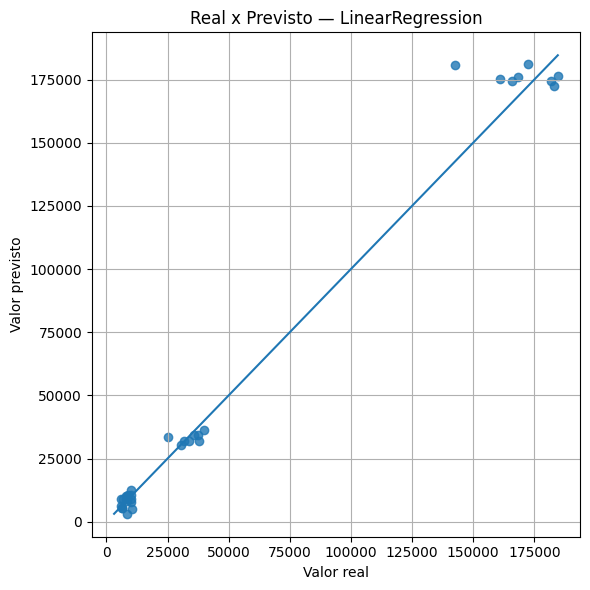

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_preds, alpha=0.8)
lim_min = min(y_test.min(), best_preds.min())
lim_max = max(y_test.max(), best_preds.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max])
ax.set_xlabel("Valor real")
ax.set_ylabel("Valor previsto")
ax.set_title(f"Real x Previsto — {best_model_name}")
plt.tight_layout()
fig.savefig("grafico_real_vs_previsto.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.3. Interpretação do modelo linear

In [ ]:
# refazemos o pipeline em formato denso para visualizar coeficientes
dense_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), weather_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder(dense=True))
        ]), cat_cols)
    ],
    sparse_threshold=0
)

linear_dense = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", LinearRegression())
])

linear_dense.fit(X_train, y_train)

feature_names = linear_dense.named_steps["preprocessor"].get_feature_names_out()
coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": linear_dense.named_steps["model"].coef_
    })
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
coef_df

,feature,coef
5,cat__Crop_Oil palm fruit,120691.580537
7,"cat__Crop_Rubber, natural",-48774.841930
4,"cat__Crop_Cocoa, beans",-47387.271193
6,"cat__Crop_Rice, paddy",-24529.467415
1,num__Specific Humidity at 2 Meters (g/kg),23663.601585
3,num__Temperature at 2 Meters (C),-19798.528575
2,num__Relative Humidity at 2 Meters (%),-19617.517645
0,num__Precipitation (mm day-1),2864.136986


**Leitura gerencial dos coeficientes:**

Os maiores coeficientes estão ligados às variáveis de **cultura**, reforçando que o tipo de plantação é o fator dominante nesta base. Entre as variáveis climáticas, umidade específica, temperatura e umidade relativa aparecem com maior peso relativo.

## 6. Conclusões finais

### Entrega 1 — Machine Learning
- A base está limpa, sem nulos e sem duplicatas completas.
- Há **4 culturas** e **39 cenários climáticos únicos**.
- A clusterização mostrou que a variável **Crop** domina a separação dos grupos.
- O DBSCAN encontrou **cenários climáticos raros**, úteis para análise de anomalias.
- Entre os cinco modelos, a **Regressão Linear** teve o melhor desempenho geral no teste.


## Limitações do trabalho
- A base é pequena (**156 linhas**).
- O bloco climático se repete entre culturas, o que reduz a variabilidade independente do dataset.
- Os resultados são úteis como prova de conceito, mas não suficientes para afirmar causalidade agronômica robusta.


## 7. Referências utilizadas na construção da solução

### Materiais FIAP
- Capítulo de **Regressão Supervisionada**: métricas MAE, MSE, RMSE e R²; uso de hold-out, K-Fold e pipelines.
- Capítulo de **Machine Learning Sem Supervisão**: clusterização, outliers, DBSCAN, K-Means e PCA.
- Capítulos de **Cloud Computing**, **Segurança** e **Direito Digital** para fundamentar a decisão de hospedagem.

